# Sprint 1a — Preparação dos Dados

**Projeto Aplicado:** Identificação de Regimes Operacionais em Moagem Industrial  
**Notebook:** `a_preparacao_dados.ipynb`  

---

**Objetivo:** Preparar os dados do zero — carregar o dataset bruto extraído do PI System, realizar inspeção completa, aplicar limpeza e tratamento de outliers. Documentar cada etapa com quantidade de registros removidos, motivo e impacto.

**Entrada:** `data/raw/dados_unificados.parquet` (~824k linhas, 26 colunas, intervalo 1 min, ago/2024 – mar/2026)

**Saídas:**
- `data/processed/dataset_limpo.parquet` — dataset limpo para EDA e clustering
- Banco PostgreSQL: `dados_brutos`, `dados_limpos` + todas as tabelas de metadados `s1a_*`
- Figuras: localmente em `figures/` e no banco para o dashboard

**Etapas:**
1. Setup e carregamento dos dados brutos
2. Inspeção inicial (shape, tipos, período, nulos, duplicados)
3. Análise de valores negativos
4. Análise de valores ausentes (contagem + gaps temporais)
5. Limpeza:
   - Substituição de negativos por zero
   - Exclusão de períodos de falha do servidor PI System
   - Remoção de instabilidade operacional (alimentação zero, moinho desligado)
   - Tratamento híbrido de NaN (3 regras: drop rows, drop cols, mediana mensal)
6. Tratamento de outliers (IQR + Z-Score)
7. Comparação estatística antes/depois
8. Salvamento no banco e localmente

## 1 - Setup do Projeto

**Objetivo:** Configurar caminhos absolutos, imports e conexão com o banco de dados para que o notebook rode de qualquer diretório.

**Parâmetros:**
- `PROJECT_ROOT`: raiz do projeto no Google Drive
- `SCRIPTS_DIR`: diretório da venv com `db_utils.py`

**Justificativa:** Centralizar a configuração em uma célula garante que todas as referências a arquivos e ao banco sejam consistentes, independente de onde o notebook é executado.

In [71]:
# ==============================================================================
# Setup: caminhos e imports do projeto
# ==============================================================================
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Suprimir warnings visuais para manter o notebook limpo
warnings.filterwarnings("ignore", category=FutureWarning)

# Raiz do projeto — resolve independente de onde o notebook é executado
PROJECT_ROOT = Path(r"C:\ScriptsDatamindsPIP\4-Projeto aplicado")

# Caminhos padronizados
DATA_RAW     = PROJECT_ROOT / "data" / "raw"
DATA_PROC    = PROJECT_ROOT / "data" / "processed"
DATA_LABEL   = PROJECT_ROOT / "data" / "labeled"
FIGURES_DIR  = PROJECT_ROOT / "figures" / "01_sprint1"
MODELS_DIR   = PROJECT_ROOT / "models"
REPORTS_DIR  = PROJECT_ROOT / "reports"

# Adicionar diretório de scripts ao path (para importar db_utils)
SCRIPTS_DIR = PROJECT_ROOT / "utils"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

# Garantir que os diretórios de saída existem
for d in [DATA_PROC, DATA_LABEL, FIGURES_DIR, MODELS_DIR, REPORTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Importar módulo de acesso ao banco de dados
from db_utils import salvar_dataframe, salvar_imagem, carregar_dataframe, criar_tabelas

# Criar schema e tabelas (idempotente — seguro executar várias vezes)
criar_tabelas()

# Configurações visuais dos gráficos
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 19,
    "figure.titlesize": 21,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})
sns.set_style("whitegrid")

# Arquivo de entrada
ARQUIVO_BRUTO = DATA_RAW / "dados_unificados.parquet"

print(f"Projeto: {PROJECT_ROOT}")
print(f"Arquivo bruto: {ARQUIVO_BRUTO} (existe: {ARQUIVO_BRUTO.exists()})")


[db_utils] Schema 'otimizar_moagem_aura' e tabelas criados/verificados com sucesso
Projeto: C:\ScriptsDatamindsPIP\4-Projeto aplicado
Arquivo bruto: C:\ScriptsDatamindsPIP\4-Projeto aplicado\data\raw\dados_unificados.parquet (existe: True)


## 2 - Carregamento e Inspeção Inicial dos Dados Brutos

**Objetivo:** Carregar o dataset bruto do parquet e realizar a primeira inspeção — shape, tipos de dados, período temporal, registros duplicados e visão geral.

**Justificativa:** Antes de qualquer tratamento, é fundamental conhecer a estrutura dos dados: quantas linhas e colunas temos, se há duplicatas no timestamp, qual o período coberto e quais são os tipos de cada variável. Essa visão geral orienta todas as decisões de limpeza subsequentes.

In [72]:
# ==============================================================================
# 2. Carregar dados brutos e realizar inspeção inicial
# ==============================================================================

# Carregar o parquet bruto (~824k linhas, 26 colunas)
if not ARQUIVO_BRUTO.exists():
    raise FileNotFoundError(
        f"Arquivo de dados brutos não encontrado: {ARQUIVO_BRUTO}\n"
        f"Verifique se o parquet foi extraído para {DATA_RAW}/"
    )
df_bruto = pd.read_parquet(ARQUIVO_BRUTO)

# Validar coluna Timestamp
if "Timestamp" not in df_bruto.columns:
    raise KeyError(
        f"Coluna 'Timestamp' não encontrada no parquet. "
        f"Colunas disponíveis: {df_bruto.columns.tolist()[:5]}..."
    )

# Converter coluna Timestamp para datetime e definir como índice temporal
df_bruto["Timestamp"] = pd.to_datetime(df_bruto["Timestamp"], errors="coerce")
n_nat = df_bruto["Timestamp"].isna().sum()
if n_nat > 0:
    print(f"  AVISO: {n_nat} timestamps inválidos convertidos para NaT (serão removidos)")
    df_bruto = df_bruto.dropna(subset=["Timestamp"])

df_bruto = df_bruto.set_index("Timestamp").sort_index()

# Criar lista de variáveis de processo (todas exceto o índice Timestamp)
VARIAVEIS = df_bruto.columns.tolist()

print("=" * 60)
print("INSPEÇÃO INICIAL DOS DADOS BRUTOS")
print("=" * 60)
print(f"Shape: {df_bruto.shape[0]:,} linhas x {df_bruto.shape[1]} colunas")
print(f"Período: {df_bruto.index.min()} a {df_bruto.index.max()}")
print(f"Duração: {(df_bruto.index.max() - df_bruto.index.min()).days} dias")
print(f"Intervalo médio: {df_bruto.index.to_series().diff().median()}")
print(f"Duplicatas no índice: {df_bruto.index.duplicated().sum()}")
print(f"Memória: {df_bruto.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print()
print("Tipos de dados:")
print(df_bruto.dtypes.value_counts())
print()
print("Primeiras linhas:")
df_bruto.head(3)

INSPEÇÃO INICIAL DOS DADOS BRUTOS
Shape: 830,881 linhas x 27 colunas
Período: 2024-08-01 00:00:00 a 2026-03-01 00:00:00
Duração: 577 dias
Intervalo médio: 0 days 00:01:00
Duplicatas no índice: 0
Memória: 186.1 MB

Tipos de dados:
float64    27
Name: count, dtype: int64

Primeiras linhas:


,1010_BRITAGEM _ SL01 _ NÍVEL_pipoint,1025_RETOMADA_SL01_NIVEL_pipoint,1025_RETOMADA _ AL01 _ SETPOINT_pipoint,1025_RETOMADA _ AL02 _ SETPOINT_pipoint,1025_RETOMADA _ AL03 _ SETPOINT_pipoint,1025_RETOMADA _ TR02 _ BALANÇA_pipoint,1025_RETOMADA _ TR02 _ CORRENTE_pipoint,1030_MOAGEM _ CX01 _ NÍVEL_pipoint,1030_MOAGEM _ HCALIMENTAÇÃO _ DENSIDADE_pipoint,1030_MOAGEM _ HCALIMENTAÇÃO _ VAZÃO_pipoint,...,1030_MOAGEM _ MO01 _ POTÊNCIA_pipoint,1030_MOAGEM _ MO01 _ ROTAÇÃO_pipoint,1030_MOAGEM _ MO01 _ TORQUE_pipoint,1030_MOAGEM _ TR01 _ TRANSMISSORDEPESO_pipoint,1035_ESPESSAMENTO _ EP01ALIMENTAÇÃOCIL _ VAZÃO_pipoint,1035_ESPESSAMENTO _ EP01 _ PH_pipoint,1035_ESPESSAMENTO _ EP01 _ PRESSÃOSAÍDA_pipoint,1065_DETOX _ CX01 _ NÍVEL_pipoint,2020_SISTEMADEÁGUA _ TQ01 _ NÍVEL_pipoint,2020_SISTEMADEÁGUA _ TQ02 _ NÍVEL_pipoint
Timestamp,,,,,,,,,,,,,,,,,,,,,
2024-08-01 00:00:00,21.44165,NaN,90.0,95.0,85.0,216.223785,25.448626,69.626785,1785.53540,576.016052,...,2446.86157,849.443000,551.729000,4.154689,386.5022,10.709608,172.038727,83.47025,75.98498,95.753845
2024-08-01 00:01:00,21.44165,NaN,90.0,95.0,85.0,219.617615,25.978641,68.632990,1789.76025,427.645966,...,2448.97119,849.038757,558.171448,2.157826,384.6967,10.709100,172.093460,81.56178,76.27816,95.738700
2024-08-01 00:02:00,21.44165,NaN,90.0,95.0,85.0,208.265500,25.017794,69.079480,1797.13428,465.074860,...,2433.32031,848.634500,552.124600,1.974229,372.6496,10.708590,172.161591,82.17626,76.52000,95.721480


## 3 - Estatísticas Descritivas dos Dados Brutos

**Objetivo:** Gerar o resumo estatístico completo (count, mean, std, min, quartis, max) de todas as variáveis para ter uma linha de base antes de qualquer tratamento.

**Justificativa:** As estatísticas descritivas revelam amplitudes inesperadas (mínimos negativos, máximos extremos), assimetrias e ajudam a definir os critérios de limpeza. Serão comparadas com as estatísticas pós-limpeza na etapa 7.

In [73]:
# ==============================================================================
# 3. Estatísticas descritivas — linha de base antes da limpeza
# ==============================================================================

# Guardar estatísticas antes da limpeza para comparação posterior
stats_antes = df_bruto.describe().T
stats_antes.index.name = "variavel"

print("Estatísticas descritivas dos dados brutos:")
stats_antes

Estatísticas descritivas dos dados brutos:


,count,mean,std,min,25%,50%,75%,max
variavel,,,,,,,,
1010_BRITAGEM _ SL01 _ NÍVEL_pipoint,824540.0,54.925074,23.439535,-6.252577,47.443357,60.405334,69.957030,103.172607
1025_RETOMADA_SL01_NIVEL_pipoint,328979.0,49.491933,20.270653,-2.545166,35.272217,47.222900,61.492920,103.161621
1025_RETOMADA _ AL01 _ SETPOINT_pipoint,824293.0,73.415238,154.155936,0.000000,61.000000,73.000000,85.000000,65535.000000
1025_RETOMADA _ AL02 _ SETPOINT_pipoint,824293.0,91.760459,18.059715,0.000000,85.000000,96.000000,100.000000,9493.000000
1025_RETOMADA _ AL03 _ SETPOINT_pipoint,824293.0,79.537412,78.532367,0.000000,72.000000,80.000000,88.000000,65535.000000
1025_RETOMADA _ TR02 _ BALANÇA_pipoint,824539.0,236.226247,84.021493,-15.119471,228.051209,255.999786,283.902089,425.119400
1025_RETOMADA _ TR02 _ CORRENTE_pipoint,817450.0,32.889096,14.485648,0.000000,25.198397,27.388106,48.539956,105.853958
1030_MOAGEM _ CX01 _ NÍVEL_pipoint,824539.0,67.443914,15.978137,-3.276440,56.783344,68.318480,78.159335,103.113846
1030_MOAGEM _ HCALIMENTAÇÃO _ DENSIDADE_pipoint,824540.0,1706.705511,238.274277,455.260742,1587.408998,1738.023805,1806.487212,3941.256000


## 4 - Análise de Valores Negativos

**Objetivo:** Identificar e quantificar valores negativos em cada variável. Variáveis de processo industrial (vazão, pressão, corrente, potência, etc.) não podem assumir valores negativos fisicamente — esses valores indicam falha de leitura do sensor ou do sistema de aquisição (PI System).

**Parâmetros:**
- Critério: qualquer valor `< 0` é considerado fisicamente impossível

**Tratamento (aplicado na etapa de limpeza):**
- Valores negativos são **substituídos por zero** — interpretados como sensor desligado ou leitura inválida
- Essa abordagem preserva mais registros do que a remoção de linhas inteiras

**Justificativa:** Remover linhas inteiras por causa de um único valor negativo descartaria dados válidos das demais variáveis. Substituir por zero é mais conservador e consistente com a interpretação de que o sensor não estava operando naquele momento.

Variáveis com valores negativos: 13 de 27
Total de valores negativos: 443,221



,variavel,contagem_negativos,percentual
8,1030_MOAGEM _ TR01 _ TRANSMISSORDEPESO_pipoint,355965,42.8419
7,1030_MOAGEM _ MO01_VAZAO_pipoint,21027,2.5307
2,1025_RETOMADA _ TR02 _ BALANÇA_pipoint,19078,2.2961
6,1030_MOAGEM _ MO01ÁGUADESCARGAMOINHO _ VAZÃO_p...,16304,1.9623
5,1030_MOAGEM _ HC _ PRESSÃO_pipoint,12972,1.5612
4,1030_MOAGEM _ HCALIMENTAÇÃO _ VAZÃO_pipoint,12713,1.5301
0,1010_BRITAGEM _ SL01 _ NÍVEL_pipoint,3556,0.4280
10,1035_ESPESSAMENTO _ EP01 _ PRESSÃOSAÍDA_pipoint,762,0.0917
3,1030_MOAGEM _ CX01 _ NÍVEL_pipoint,451,0.0543
9,1035_ESPESSAMENTO _ EP01ALIMENTAÇÃOCIL _ VAZÃO...,226,0.0272


[db_utils] Imagem 'negativos_por_variavel' salva para etapa S1a


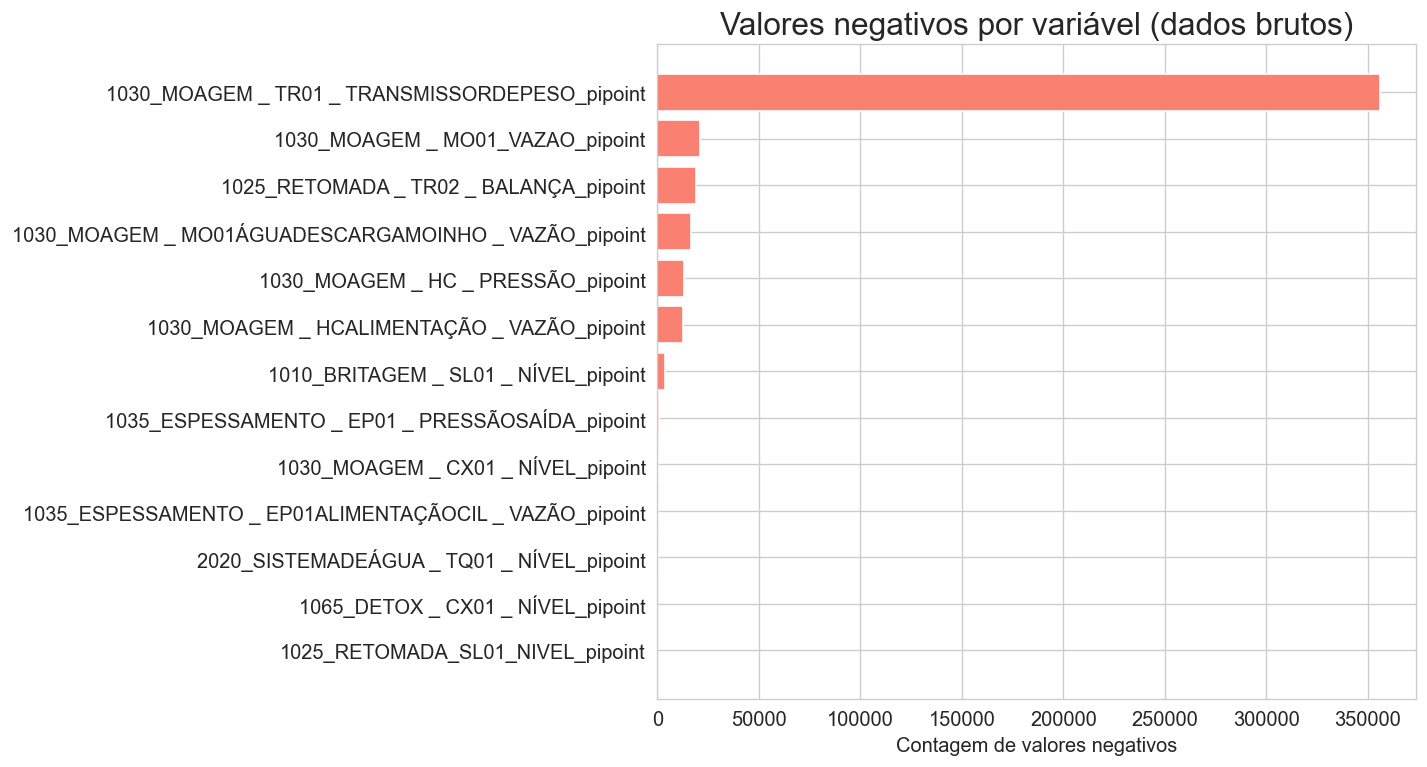

In [74]:
# ==============================================================================
# 4. Análise de valores negativos por variável
# ==============================================================================

# Contar negativos por variável
negativos_por_var = []
for col in VARIAVEIS:
    n_neg = (df_bruto[col] < 0).sum()
    if n_neg > 0:
        negativos_por_var.append({
            "variavel": col,
            "contagem_negativos": int(n_neg),
            "percentual": round(n_neg / len(df_bruto) * 100, 4),
        })

df_negativos = pd.DataFrame(negativos_por_var)

if len(df_negativos) > 0:
    df_negativos = df_negativos.sort_values("contagem_negativos", ascending=False)
    print(f"Variáveis com valores negativos: {len(df_negativos)} de {len(VARIAVEIS)}")
    print(f"Total de valores negativos: {df_negativos['contagem_negativos'].sum():,}")
    print()
    display(df_negativos)

    # Visualização: barras horizontais de contagem de negativos
    fig, ax = plt.subplots(figsize=(12, max(4, len(df_negativos) * 0.5)))
    ax.barh(df_negativos["variavel"], df_negativos["contagem_negativos"], color="salmon")
    ax.set_xlabel("Contagem de valores negativos")
    ax.set_title("Valores negativos por variável (dados brutos)")
    ax.invert_yaxis()
    plt.tight_layout()

    # Salvar figura localmente e no banco
    fig.savefig(FIGURES_DIR / "S1a_01_negativos_por_variavel.png", dpi=150, bbox_inches="tight")
    salvar_imagem("S1a", "negativos_por_variavel", fig, "S1a_01_negativos_por_variavel.png")
    plt.show()
else:
    print("Nenhuma variável apresenta valores negativos.")

## 5 - Análise de Valores Ausentes

**Objetivo:** Quantificar valores ausentes (NaN) por variável e identificar gaps temporais contínuos — intervalos onde uma variável ficou sem dados por períodos prolongados.

**Parâmetros:**
- Gap mínimo reportado: `> 5 minutos` (5 registros consecutivos ausentes)

**Justificativa:** Valores ausentes podem indicar falha de sensor, parada de equipamento ou perda de comunicação com o PI System. Gaps longos podem exigir exclusão do período inteiro em vez de interpolação. A análise de gaps ajuda a decidir a estratégia de tratamento (interpolação para gaps curtos, exclusão para gaps longos).

Valores ausentes por variável:


,variavel,total_registros,ausentes,percentual
1,1025_RETOMADA_SL01_NIVEL_pipoint,830881,501902,60.4060
18,1030_MOAGEM _ MO01 _ ROTAÇÃO_pipoint,830881,31554,3.7977
19,1030_MOAGEM _ MO01 _ TORQUE_pipoint,830881,31553,3.7975
6,1025_RETOMADA _ TR02 _ CORRENTE_pipoint,830881,13431,1.6165
17,1030_MOAGEM _ MO01 _ POTÊNCIA_pipoint,830881,13410,1.6139
15,1030_MOAGEM _ MO01 _ CORRENTE_pipoint,830881,13410,1.6139
9,1030_MOAGEM _ HCALIMENTAÇÃO _ VAZÃO_pipoint,830881,6973,0.8392
10,1030_MOAGEM _ HC _ PRESSÃO_pipoint,830881,6751,0.8125
22,1035_ESPESSAMENTO _ EP01 _ PH_pipoint,830881,6641,0.7993
4,1025_RETOMADA _ AL03 _ SETPOINT_pipoint,830881,6588,0.7929


[db_utils] Imagem 'ausentes_por_variavel' salva para etapa S1a


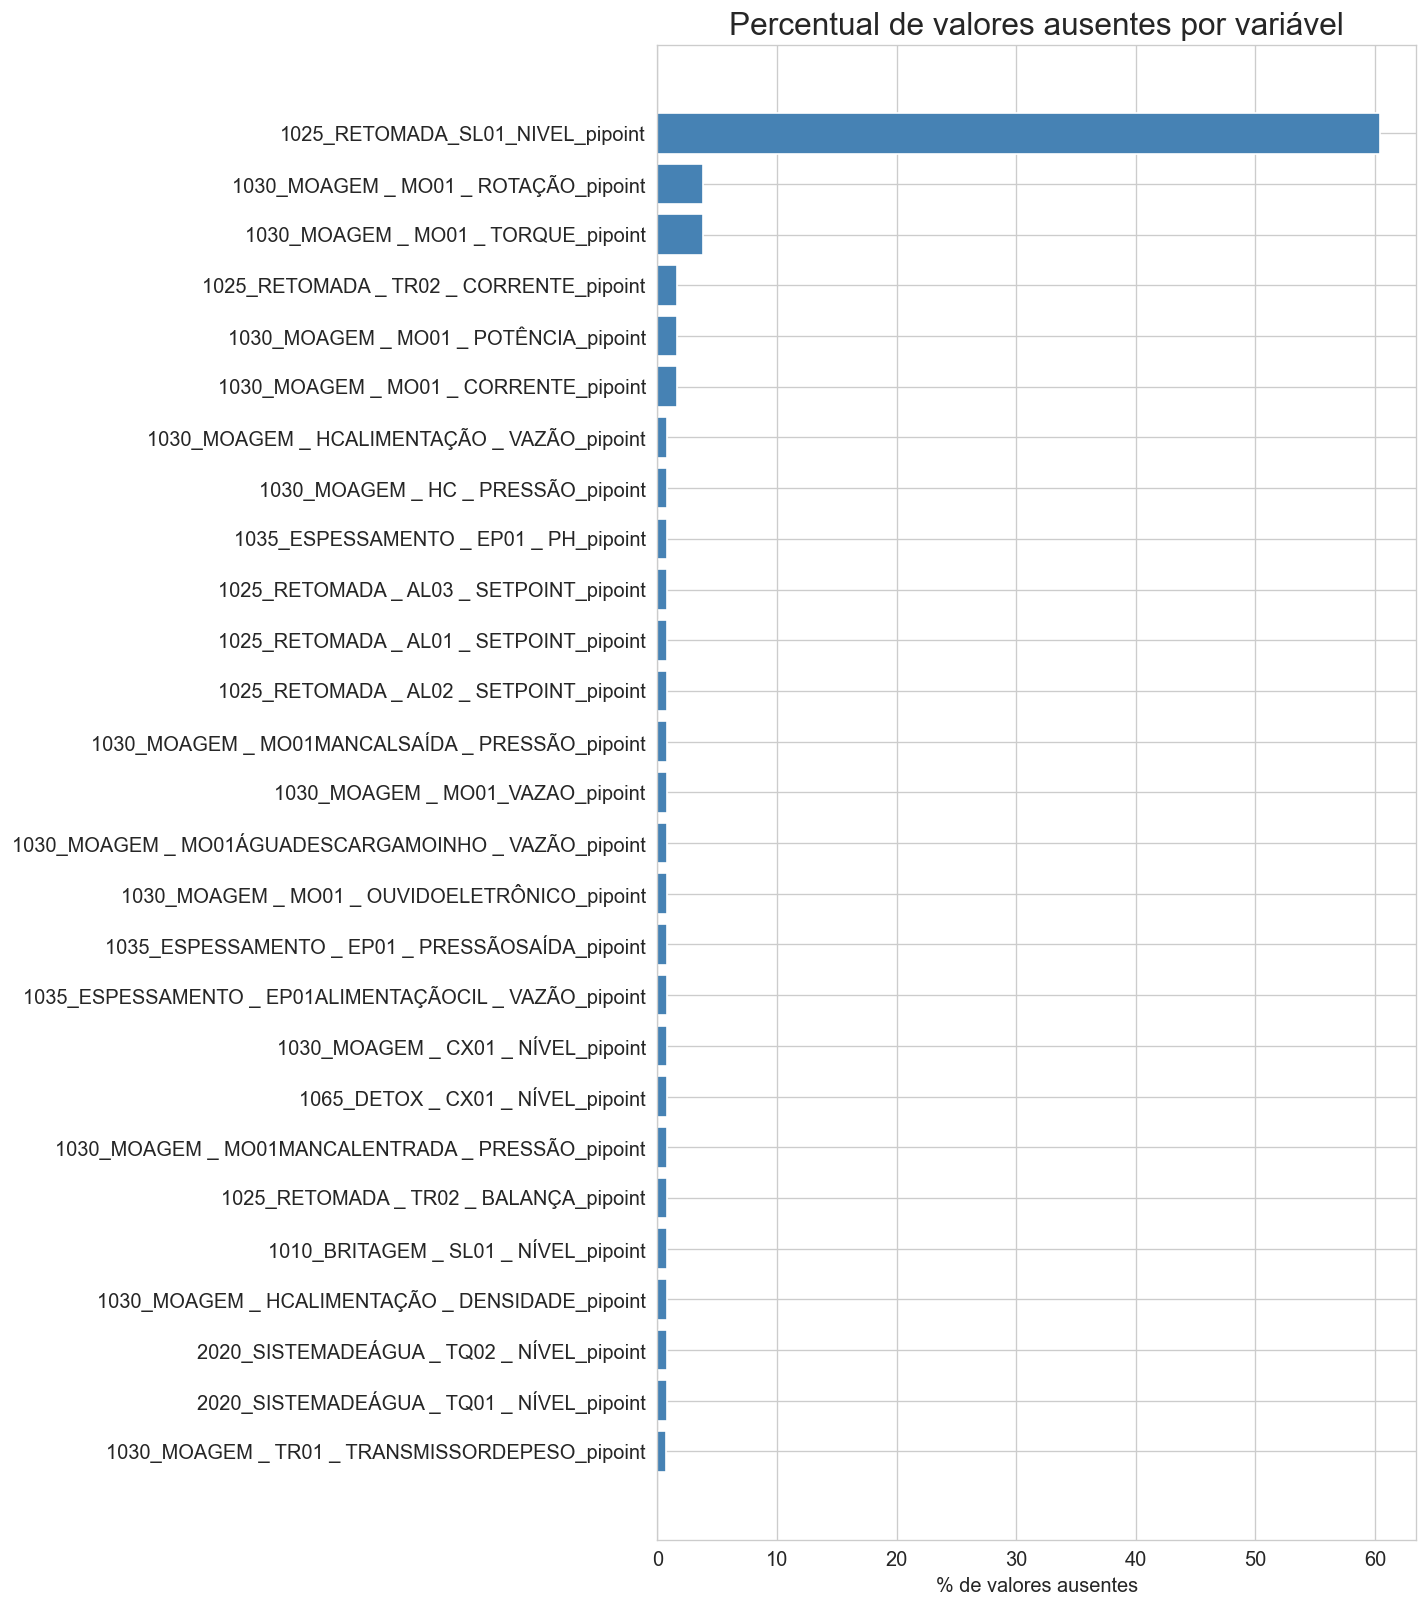


Gaps contínuos > 5 min encontrados: 645


,variavel,gap_inicio,gap_fim,duracao_minutos
25,1025_RETOMADA_SL01_NIVEL_pipoint,2024-08-01 00:00:00,2025-07-15 11:15:00,501796
458,1030_MOAGEM _ MO01 _ TORQUE_pipoint,2025-01-30 15:16:00,2025-02-18 08:41:00,26966
443,1030_MOAGEM _ MO01 _ ROTAÇÃO_pipoint,2025-02-05 16:42:00,2025-02-18 08:41:00,18240
442,1030_MOAGEM _ MO01 _ ROTAÇÃO_pipoint,2025-01-30 15:16:00,2025-02-05 16:40:00,8725
140,1025_RETOMADA _ TR02 _ CORRENTE_pipoint,2025-01-30 15:16:00,2025-02-05 14:06:00,8571
420,1030_MOAGEM _ MO01 _ POTÊNCIA_pipoint,2025-01-30 15:16:00,2025-02-05 12:31:00,8476
370,1030_MOAGEM _ MO01 _ CORRENTE_pipoint,2025-01-30 15:16:00,2025-02-05 12:31:00,8476
211,1030_MOAGEM _ HCALIMENTAÇÃO _ VAZÃO_pipoint,2025-01-30 15:16:00,2025-01-31 19:20:00,1685
37,1025_RETOMADA _ AL01 _ SETPOINT_pipoint,2025-01-30 15:16:00,2025-01-31 19:20:00,1685
63,1025_RETOMADA _ AL02 _ SETPOINT_pipoint,2025-01-30 15:16:00,2025-01-31 19:20:00,1685


In [75]:
# ==============================================================================
# 5. Análise de valores ausentes — contagem e gaps temporais
# ==============================================================================

# --- 5.1 Contagem de ausentes por variável ---
ausentes_por_var = []
for col in VARIAVEIS:
    n_miss = df_bruto[col].isna().sum()
    ausentes_por_var.append({
        "variavel": col,
        "total_registros": len(df_bruto),
        "ausentes": int(n_miss),
        "percentual": round(n_miss / len(df_bruto) * 100, 4),
    })

df_ausentes = pd.DataFrame(ausentes_por_var).sort_values("ausentes", ascending=False)
print("Valores ausentes por variável:")
display(df_ausentes[df_ausentes["ausentes"] > 0])

# Visualização de ausentes
vars_com_ausentes = df_ausentes[df_ausentes["ausentes"] > 0]
if len(vars_com_ausentes) > 0:
    fig, ax = plt.subplots(figsize=(12, max(4, len(vars_com_ausentes) * 0.5)))
    ax.barh(vars_com_ausentes["variavel"], vars_com_ausentes["percentual"], color="steelblue")
    ax.set_xlabel("% de valores ausentes")
    ax.set_title("Percentual de valores ausentes por variável")
    ax.invert_yaxis()
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "S1a_02_ausentes_por_variavel.png", dpi=150, bbox_inches="tight")
    salvar_imagem("S1a", "ausentes_por_variavel", fig, "S1a_02_ausentes_por_variavel.png")
    plt.show()

# --- 5.2 Identificação de gaps temporais contínuos ---
GAP_MINIMO_MIN = 5  # reportar gaps maiores que 5 minutos

gaps_encontrados = []
for col in VARIAVEIS:
    # Identificar sequências contínuas de NaN
    is_null = df_bruto[col].isna()
    if not is_null.any():
        continue

    # Encontrar início e fim de cada sequência de NaN
    changes = is_null.ne(is_null.shift())
    groups = changes.cumsum()
    null_groups = df_bruto[is_null].groupby(groups[is_null])

    for _, group in null_groups:
        duracao = len(group)  # cada registro = 1 minuto
        if duracao >= GAP_MINIMO_MIN:
            gaps_encontrados.append({
                "variavel": col,
                "gap_inicio": group.index.min(),
                "gap_fim": group.index.max(),
                "duracao_minutos": duracao,
            })

df_gaps = pd.DataFrame(gaps_encontrados)
if len(df_gaps) > 0:
    df_gaps = df_gaps.sort_values("duracao_minutos", ascending=False)
    print(f"\nGaps contínuos > {GAP_MINIMO_MIN} min encontrados: {len(df_gaps)}")
    display(df_gaps.head(20))
else:
    print(f"\nNenhum gap contínuo > {GAP_MINIMO_MIN} minutos encontrado.")

## 6 - Salvar Dados Brutos e Metadados de Inspeção no Banco

**Objetivo:** Persistir os dados brutos e todos os metadados de inspeção (resumo da extração, negativos, ausentes, gaps) no PostgreSQL antes de iniciar a limpeza.

**Justificativa:** Salvar no banco neste ponto garante rastreabilidade — o dashboard pode exibir a análise dos dados brutos mesmo que a limpeza ainda não tenha sido executada. Também serve como ponto de referência para comparação antes/depois.

In [76]:
# ==============================================================================
# 6. Salvar dados brutos e metadados de inspeção no PostgreSQL
# ==============================================================================

try:
    # --- 6.1 Dados brutos (tabela principal — mesma estrutura do DataFrame) ---
    salvar_dataframe(df_bruto.reset_index(), "dados_brutos")

    # --- 6.2 Resumo da extração ---
    df_resumo_ext = pd.DataFrame([{
        "total_rows": len(df_bruto),
        "total_vars": len(VARIAVEIS),
        "periodo_inicio": df_bruto.index.min(),
        "periodo_fim": df_bruto.index.max(),
        "arquivo_origem": str(ARQUIVO_BRUTO.name),
    }])
    salvar_dataframe(df_resumo_ext, "s1a_resumo_extracao")

    # --- 6.3 Resumo de negativos ---
    if len(df_negativos) > 0:
        salvar_dataframe(df_negativos, "s1a_resumo_negativos")
    else:
        print("[db_utils] Sem valores negativos para salvar em s1a_resumo_negativos")

    # --- 6.4 Resumo de ausentes ---
    salvar_dataframe(df_ausentes, "s1a_resumo_ausentes")

    # --- 6.5 Gaps temporais ---
    if len(df_gaps) > 0:
        salvar_dataframe(df_gaps, "s1a_gaps_ausentes")
    else:
        print("[db_utils] Sem gaps para salvar em s1a_gaps_ausentes")

    print("\nDados brutos e metadados de inspeção salvos no banco.")

except Exception as e:
    print(f"\nAVISO: Falha ao salvar no PostgreSQL — {e}")
    print("O notebook continuará normalmente; os dados serão salvos localmente ao final.")

[db_utils] dados_brutos: 500,000 / 830,881 (60.2%)
[db_utils] dados_brutos: 830,881 / 830,881 (100.0%)
[db_utils] 830,881 linhas salvas em otimizar_moagem_aura.dados_brutos
[db_utils] 1 linhas salvas em otimizar_moagem_aura.s1a_resumo_extracao
[db_utils] 13 linhas salvas em otimizar_moagem_aura.s1a_resumo_negativos
[db_utils] 27 linhas salvas em otimizar_moagem_aura.s1a_resumo_ausentes
[db_utils] 645 linhas salvas em otimizar_moagem_aura.s1a_gaps_ausentes

Dados brutos e metadados de inspeção salvos no banco.


## 7 - Limpeza dos Dados

**Objetivo:** Aplicar as etapas de limpeza sequencialmente, documentando a quantidade de registros removidos em cada passo.

**Etapas de limpeza (nesta ordem):**
1. **Substituir negativos por zero** — sensor com leitura fisicamente impossível é interpretado como desligado
2. **Remover períodos de falha conhecidos** — intervalos onde o servidor PI System ficou indisponível (invasão hacker, falhas esporádicas) e os dados coletados são inválidos
3. **Remover instabilidade operacional** — registros onde a balança do alimentador (`TR02_BALANÇA`) é zero (sem alimentação ao moinho) ou a corrente do moinho (`MO01_CORRENTE`) é zero (moinho desligado)
4. **Tratamento híbrido de NaN (3 regras):**
   - *Regra 1* — Colunas com 3,5% a 10% de NaN: **remover as linhas** com NaN nessas colunas
   - *Regra 2* — Colunas com mais de 10% de NaN: **remover a coluna inteira** (dados insuficientes)
   - *Regra 3* — Colunas com até 3,5% de NaN: **preencher com a mediana mensal** (fallback: mediana global)

**Parâmetros:**
- `regra1_intervalo = (3.5, 10.0)` — faixa de % NaN para remoção de linhas
- `regra2_threshold = 10.0` — limiar de % NaN para remoção de colunas
- `regra3_intervalo = (0.0, 3.5)` — faixa de % NaN para preenchimento com mediana

**Justificativa:** A abordagem híbrida equilibra preservação de dados e qualidade. Colunas com poucos NaN são preenchidas com mediana mensal (mantém sazonalidade), colunas intermediárias têm linhas removidas, e colunas com muitos NaN são descartadas para não introduzir viés. Os intervalos de exclusão temporal garantem que dados de períodos com falha de infraestrutura não contaminem a análise.

In [77]:
# ==============================================================================
# 7. Limpeza dos dados — etapas sequenciais com documentação
# ==============================================================================

# Registrar quantidade de linhas em cada etapa
etapas_limpeza = []
df = df_bruto.copy()
rows_inicio = len(df)

# --- Etapa 1: Substituir valores negativos por zero ---
# Negativos indicam falha de sensor; substituir por 0 preserva as demais colunas
rows_antes = len(df)
colunas_com_negativos = [col for col in VARIAVEIS if (df[col] < 0).any()]
n_valores_substituidos = 0
for col in colunas_com_negativos:
    mask = df[col] < 0
    n_valores_substituidos += mask.sum()
    df.loc[mask, col] = 0

etapas_limpeza.append({
    "etapa": "1_negativos_para_zero",
    "descricao": f"Substituição de valores negativos por zero ({len(colunas_com_negativos)} colunas, {n_valores_substituidos:,} valores)",
    "rows_antes": rows_antes,
    "rows_depois": len(df),
    "rows_removidas": 0,
    "percentual": 0.0,
})
print(f"Etapa 1: {n_valores_substituidos:,} valores negativos substituídos por zero em {len(colunas_com_negativos)} colunas")

# --- Etapa 2: Remover períodos de falha conhecidos ---
# Intervalos com dados inválidos por falha de infraestrutura (servidor PI System)
intervalos_exclusao = [
    ("2024-10-11 05:00", "2024-10-25 17:00", "Falha de servidor — invasão hacker"),
    ("2025-01-29 13:00", "2025-01-31 15:10", "Falha de servidor — consequência invasão hacker"),
    ("2025-03-11 10:00", "2025-03-12 12:00", "Falha esporádica de servidor"),
]

rows_antes = len(df)
exclusoes_temporais = []

for dt_ini, dt_fim, motivo in intervalos_exclusao:
    mask_periodo = (df.index >= dt_ini) & (df.index <= dt_fim)
    n_removidas = mask_periodo.sum()
    if n_removidas > 0:
        exclusoes_temporais.append({
            "inicio": pd.Timestamp(dt_ini),
            "fim": pd.Timestamp(dt_fim),
            "motivo": motivo,
            "rows_removidas": int(n_removidas),
        })
        df = df[~mask_periodo]
        print(f"  Excluído: {dt_ini} a {dt_fim} — {motivo} ({n_removidas:,} linhas)")

etapas_limpeza.append({
    "etapa": "2_exclusao_temporal",
    "descricao": f"Remoção de {len(intervalos_exclusao)} períodos com falha de servidor PI System",
    "rows_antes": rows_antes,
    "rows_depois": len(df),
    "rows_removidas": rows_antes - len(df),
    "percentual": round((rows_antes - len(df)) / rows_antes * 100, 2),
})

# Salvar exclusões temporais no banco
df_exclusoes = pd.DataFrame(exclusoes_temporais)
if len(df_exclusoes) > 0:
    salvar_dataframe(df_exclusoes, "s1a_exclusoes_temporais")

# --- Etapa 3: Remover instabilidade operacional ---
# 3.1 — Alimentação zero: balança do alimentador TR02 = 0 (moinho sem carga)
COL_BALANCA = "1025_RETOMADA _ TR02 _ BALANÇA_pipoint"
if COL_BALANCA not in df.columns:
    _candidates = [c for c in df.columns if 'BALANÇA' in c.upper()]
    if _candidates:
        COL_BALANCA = _candidates[0]
        print(f"  AVISO: Usando coluna alternativa para balança: {COL_BALANCA}")
    else:
        raise KeyError("Coluna de balança (alimentação) não encontrada no dataset.")
rows_antes = len(df)
mask_sem_alim = df[COL_BALANCA] == 0
df = df[~mask_sem_alim]

etapas_limpeza.append({
    "etapa": "3a_alimentacao_zero",
    "descricao": f"Remoção de linhas com alimentação zero (TR02_BALANÇA == 0, moinho sem carga)",
    "rows_antes": rows_antes,
    "rows_depois": len(df),
    "rows_removidas": rows_antes - len(df),
    "percentual": round((rows_antes - len(df)) / rows_antes * 100, 2),
})
print(f"Etapa 3a: {rows_antes - len(df):,} linhas removidas (alimentação zero)")

# 3.2 — Moinho desligado: corrente do moinho MO01 = 0
COL_CORRENTE = "1030_MOAGEM _ MO01 _ CORRENTE_pipoint"
if COL_CORRENTE not in df.columns:
    _candidates = [c for c in df.columns if 'MO01' in c.upper() and 'CORRENTE' in c.upper()]
    if _candidates:
        COL_CORRENTE = _candidates[0]
        print(f"  AVISO: Usando coluna alternativa para corrente: {COL_CORRENTE}")
    else:
        raise KeyError("Coluna de corrente do moinho (MO01) não encontrada no dataset.")
rows_antes = len(df)
mask_moinho_off = df[COL_CORRENTE] == 0
df = df[~mask_moinho_off]

etapas_limpeza.append({
    "etapa": "3b_moinho_desligado",
    "descricao": f"Remoção de linhas com moinho desligado (MO01_CORRENTE == 0)",
    "rows_antes": rows_antes,
    "rows_depois": len(df),
    "rows_removidas": rows_antes - len(df),
    "percentual": round((rows_antes - len(df)) / rows_antes * 100, 2),
})
print(f"Etapa 3b: {rows_antes - len(df):,} linhas removidas (moinho desligado)")

# --- Etapa 4: Tratamento híbrido de NaN (3 regras) ---
# Parâmetros das regras
REGRA1_INTERVALO = (3.5, 10.0)   # % NaN para remoção de linhas
REGRA2_THRESHOLD = 10.0           # % NaN para remoção de colunas
REGRA3_INTERVALO = (0.0, 3.5)    # % NaN para preenchimento com mediana

# Atualizar lista de variáveis (pode ter mudado se colunas forem removidas)
VARIAVEIS_ATUAL = [c for c in df.columns if c in VARIAVEIS]

# Calcular % de NaN por coluna
pct_nan = df[VARIAVEIS_ATUAL].isna().mean() * 100

print(f"\nEtapa 4: Tratamento híbrido de NaN")
print(f"  Colunas com NaN: {(pct_nan > 0).sum()} de {len(VARIAVEIS_ATUAL)}")

# --- Regra 1: Colunas com 3.5% < NaN <= 10% → remover linhas ---
cols_regra1 = pct_nan[(pct_nan > REGRA1_INTERVALO[0]) & (pct_nan <= REGRA1_INTERVALO[1])].index.tolist()
rows_antes = len(df)

if cols_regra1:
    # Máscara: qualquer NaN nas colunas da Regra 1
    mask_nan_r1 = df[cols_regra1].isna().any(axis=1)
    df = df[~mask_nan_r1]
    print(f"  Regra 1 ({REGRA1_INTERVALO[0]}%-{REGRA1_INTERVALO[1]}%): {len(cols_regra1)} colunas → {mask_nan_r1.sum():,} linhas removidas")
    for col in cols_regra1:
        print(f"    - {col}: {pct_nan[col]:.2f}% NaN")
else:
    print(f"  Regra 1: nenhuma coluna com NaN entre {REGRA1_INTERVALO[0]}% e {REGRA1_INTERVALO[1]}%")

etapas_limpeza.append({
    "etapa": "4a_nan_regra1_drop_rows",
    "descricao": f"Regra 1: remoção de linhas com NaN em colunas com {REGRA1_INTERVALO[0]}%-{REGRA1_INTERVALO[1]}% ausentes ({len(cols_regra1)} colunas)",
    "rows_antes": rows_antes,
    "rows_depois": len(df),
    "rows_removidas": rows_antes - len(df),
    "percentual": round((rows_antes - len(df)) / rows_antes * 100, 2) if rows_antes > 0 else 0,
})

# --- Regra 2: Colunas com NaN > 10% → remover coluna inteira ---
# Recalcular % NaN após Regra 1
pct_nan_r2 = df[VARIAVEIS_ATUAL].isna().mean() * 100
cols_regra2 = pct_nan_r2[pct_nan_r2 > REGRA2_THRESHOLD].index.tolist()
colunas_removidas = []

if cols_regra2:
    colunas_removidas = cols_regra2.copy()
    df = df.drop(columns=cols_regra2)
    # Atualizar lista de variáveis
    VARIAVEIS_ATUAL = [c for c in VARIAVEIS_ATUAL if c not in cols_regra2]
    print(f"  Regra 2 (>{REGRA2_THRESHOLD}%): {len(cols_regra2)} colunas REMOVIDAS:")
    for col in cols_regra2:
        print(f"    - {col}: {pct_nan_r2[col]:.2f}% NaN")
else:
    print(f"  Regra 2: nenhuma coluna com NaN > {REGRA2_THRESHOLD}%")

etapas_limpeza.append({
    "etapa": "4b_nan_regra2_drop_cols",
    "descricao": f"Regra 2: remoção de colunas com >{REGRA2_THRESHOLD}% ausentes ({len(cols_regra2)} colunas: {', '.join(cols_regra2) if cols_regra2 else 'nenhuma'})",
    "rows_antes": len(df),
    "rows_depois": len(df),
    "rows_removidas": 0,
    "percentual": 0.0,
})

# --- Regra 3: Colunas com 0% < NaN <= 3.5% → preencher com mediana mensal ---
# Recalcular % NaN após Regras 1 e 2
pct_nan_r3 = df[VARIAVEIS_ATUAL].isna().mean() * 100
cols_regra3 = pct_nan_r3[(pct_nan_r3 > REGRA3_INTERVALO[0]) & (pct_nan_r3 <= REGRA3_INTERVALO[1])].index.tolist()
rows_antes_r3 = len(df)

if cols_regra3:
    # Adicionar colunas temporárias de ano e mês para agrupamento
    df["__ano__"] = df.index.year
    df["__mes__"] = df.index.month

    for col in cols_regra3:
        n_nan_antes = df[col].isna().sum()
        mediana_global = df[col].median()

        # Preencher NaN com mediana do mês correspondente
        for (ano, mes), grupo in df.groupby(["__ano__", "__mes__"]):
            mask_nan = grupo[col].isna()
            if not mask_nan.any():
                continue

            mediana_mes = grupo[col].median()
            # Se o mês inteiro é NaN, usar mediana global como fallback
            valor_fill = mediana_global if pd.isna(mediana_mes) else mediana_mes
            df.loc[mask_nan[mask_nan].index, col] = valor_fill

        n_nan_depois = df[col].isna().sum()
        print(f"  Regra 3: {col} — {n_nan_antes:,} NaN preenchidos com mediana mensal ({pct_nan_r3[col]:.2f}%)")

    # Remover colunas temporárias
    df = df.drop(columns=["__ano__", "__mes__"])
else:
    print(f"  Regra 3: nenhuma coluna com NaN entre {REGRA3_INTERVALO[0]}% e {REGRA3_INTERVALO[1]}%")

etapas_limpeza.append({
    "etapa": "4c_nan_regra3_mediana",
    "descricao": f"Regra 3: preenchimento com mediana mensal em colunas com {REGRA3_INTERVALO[0]}%-{REGRA3_INTERVALO[1]}% ausentes ({len(cols_regra3)} colunas)",
    "rows_antes": rows_antes_r3,
    "rows_depois": len(df),
    "rows_removidas": 0,
    "percentual": 0.0,
})

# Verificação final: garantir que não restam NaN
nan_restantes = df[VARIAVEIS_ATUAL].isna().sum().sum()
print(f"\nNaN restantes após tratamento: {nan_restantes}")
if nan_restantes > 0:
    # Se restaram NaN em colunas não cobertas pelas regras, dropar as linhas
    rows_antes = len(df)
    df = df.dropna(subset=VARIAVEIS_ATUAL)
    print(f"  Dropna residual: {rows_antes - len(df):,} linhas removidas")
    etapas_limpeza.append({
        "etapa": "4d_nan_residual",
        "descricao": "Remoção de linhas com NaN residuais não cobertos pelas 3 regras",
        "rows_antes": rows_antes,
        "rows_depois": len(df),
        "rows_removidas": rows_antes - len(df),
        "percentual": round((rows_antes - len(df)) / rows_antes * 100, 2) if rows_antes > 0 else 0,
    })

# Resumo parcial da limpeza (antes dos outliers)
df_limpeza = pd.DataFrame(etapas_limpeza)
print("\n" + "=" * 60)
print("RESUMO DA LIMPEZA (antes do tratamento de outliers)")
print("=" * 60)
print(f"Registros iniciais:  {rows_inicio:>10,}")
print(f"Registros atuais:    {len(df):>10,}")
print(f"Removidos até aqui:  {rows_inicio - len(df):>10,} ({(rows_inicio - len(df)) / rows_inicio * 100:.1f}%)")
if colunas_removidas:
    print(f"Colunas removidas:   {len(colunas_removidas)} ({', '.join(colunas_removidas)})")
print()
display(df_limpeza)

Etapa 1: 443,221 valores negativos substituídos por zero em 13 colunas
  Excluído: 2024-10-11 05:00 a 2024-10-25 17:00 — Falha de servidor — invasão hacker (20,881 linhas)
  Excluído: 2025-01-29 13:00 a 2025-01-31 15:10 — Falha de servidor — consequência invasão hacker (3,011 linhas)
  Excluído: 2025-03-11 10:00 a 2025-03-12 12:00 — Falha esporádica de servidor (1,561 linhas)
[db_utils] 3 linhas salvas em otimizar_moagem_aura.s1a_exclusoes_temporais
Etapa 3a: 27,022 linhas removidas (alimentação zero)
Etapa 3b: 24,764 linhas removidas (moinho desligado)

Etapa 4: Tratamento híbrido de NaN
  Colunas com NaN: 27 de 27
  Regra 1: nenhuma coluna com NaN entre 3.5% e 10.0%
  Regra 2 (>10.0%): 1 colunas REMOVIDAS:
    - 1025_RETOMADA_SL01_NIVEL_pipoint: 59.37% NaN
  Regra 3: 1010_BRITAGEM _ SL01 _ NÍVEL_pipoint — 2,030 NaN preenchidos com mediana mensal (0.27%)
  Regra 3: 1025_RETOMADA _ AL01 _ SETPOINT_pipoint — 2,171 NaN preenchidos com mediana mensal (0.29%)
  Regra 3: 1025_RETOMADA _ AL0

,etapa,descricao,rows_antes,rows_depois,rows_removidas,percentual
0,1_negativos_para_zero,Substituição de valores negativos por zero (13...,830881,830881,0,0.00
1,2_exclusao_temporal,Remoção de 3 períodos com falha de servidor PI...,830881,805428,25453,3.06
2,3a_alimentacao_zero,Remoção de linhas com alimentação zero (TR02_B...,805428,778406,27022,3.35
3,3b_moinho_desligado,Remoção de linhas com moinho desligado (MO01_C...,778406,753642,24764,3.18
4,4a_nan_regra1_drop_rows,Regra 1: remoção de linhas com NaN em colunas ...,753642,753642,0,0.00
5,4b_nan_regra2_drop_cols,Regra 2: remoção de colunas com >10.0% ausente...,753642,753642,0,0.00
6,4c_nan_regra3_mediana,Regra 3: preenchimento com mediana mensal em c...,753642,753642,0,0.00


## 8 - Tratamento de Outliers

**Objetivo:** Detectar e remover outliers univariados usando o método Z-Score (regra 3-sigma).

**Parâmetros:**
- `ZSCORE_LIMITE = 3`: número de desvios-padrão para considerar outlier (99,7% dos dados dentro de ±3σ para distribuição normal)

**Justificativa:** O método IQR (Intervalo Interquartil) foi descartado por não ser adequado para dados de processo industrial transiente. Embora o IQR seja frequentemente descrito como "não-paramétrico", o fator 1.5 de Tukey foi calibrado na distribuição normal (cercas equivalem a ~±2.7σ). Em dados multimodais — como os de moagem, com múltiplos regimes operacionais — o IQR produz um intervalo estreito centrado no modo dominante e descarta dados legítimos de outros regimes como "outliers". Em testes empíricos com este dataset, o IQR removeu 42,5% dos dados, o que evidencia eliminação de regimes operacionais, não de outliers reais.

O Z-Score (3σ) é mais conservador e apropriado para este contexto: remove apenas valores que se afastam significativamente da distribuição geral, preservando a variabilidade operacional legítima do processo.

**Referências:**
- Hubert & Van der Veeken (2008) — *Outlier Detection for Skewed Data*, KU Leuven
- NIST Engineering Statistics Handbook — *Detection of Outliers*

In [78]:
# ==============================================================================
# 8. Tratamento de outliers — Z-Score (3-sigma)
# ==============================================================================

ZSCORE_LIMITE = 3     # limiar de desvios-padrão (regra 3-sigma)

# Usar lista atualizada de variáveis (exclui colunas removidas pela Regra 2)
vars_outlier = [c for c in VARIAVEIS_ATUAL if c in df.columns]

log_outliers = []
rows_pre_outlier = len(df)

# --- Z-Score: remover valores além de ±3 desvios-padrão ---
mask_zscore_total = pd.Series(False, index=df.index)

for col in vars_outlier:
    mean_col = df[col].mean()
    std_col = df[col].std()

    if std_col == 0:
        continue  # variável constante, sem outliers possíveis

    zscore = ((df[col] - mean_col) / std_col).abs()
    mask_col = zscore > ZSCORE_LIMITE
    n_outliers = mask_col.sum()

    log_outliers.append({
        "variavel": col,
        "tecnica": "Z-Score",
        "limite_inferior": round(mean_col - ZSCORE_LIMITE * std_col, 4),
        "limite_superior": round(mean_col + ZSCORE_LIMITE * std_col, 4),
        "outliers_detectados": int(n_outliers),
        "percentual_removido": round(n_outliers / len(df) * 100, 4),
    })

    mask_zscore_total = mask_zscore_total | mask_col

# Aplicar remoção
df = df[~mask_zscore_total]

etapas_limpeza.append({
    "etapa": "5_outliers_zscore",
    "descricao": f"Remoção de outliers por Z-Score (limite={ZSCORE_LIMITE} sigma)",
    "rows_antes": rows_pre_outlier,
    "rows_depois": len(df),
    "rows_removidas": rows_pre_outlier - len(df),
    "percentual": round((rows_pre_outlier - len(df)) / rows_pre_outlier * 100, 2),
})

print(f"Z-Score (±{ZSCORE_LIMITE}σ): {rows_pre_outlier - len(df):,} linhas removidas ({(rows_pre_outlier - len(df)) / rows_pre_outlier * 100:.2f}%)")
print(f"Total após outliers: {len(df):,} linhas (de {rows_pre_outlier:,})")

# Criar DataFrame de log de outliers
df_log_outliers = pd.DataFrame(log_outliers)
display(df_log_outliers.sort_values("outliers_detectados", ascending=False).head(10))

Z-Score (±3σ): 120,657 linhas removidas (16.01%)
Total após outliers: 632,985 linhas (de 753,642)


,variavel,tecnica,limite_inferior,limite_superior,outliers_detectados,percentual_removido
4,1025_RETOMADA _ TR02 _ BALANÇA_pipoint,Z-Score,70.5188,432.9485,26139,3.4684
23,1065_DETOX _ CX01 _ NÍVEL_pipoint,Z-Score,15.0436,92.7231,19653,2.6077
19,1030_MOAGEM _ TR01 _ TRANSMISSORDEPESO_pipoint,Z-Score,-27.5567,42.4594,16731,2.2200
22,1035_ESPESSAMENTO _ EP01 _ PRESSÃOSAÍDA_pipoint,Z-Score,126.5932,221.7992,16220,2.1522
24,2020_SISTEMADEÁGUA _ TQ01 _ NÍVEL_pipoint,Z-Score,60.5779,114.1123,15101,2.0037
13,1030_MOAGEM _ MO01_VAZAO_pipoint,Z-Score,-71.2603,123.4842,14932,1.9813
17,1030_MOAGEM _ MO01 _ ROTAÇÃO_pipoint,Z-Score,535.9324,1069.0034,8576,1.1379
16,1030_MOAGEM _ MO01 _ POTÊNCIA_pipoint,Z-Score,1342.8209,3545.8959,5623,0.7461
2,1025_RETOMADA _ AL02 _ SETPOINT_pipoint,Z-Score,36.4911,147.1168,5164,0.6852
11,1030_MOAGEM _ MO01MANCALSAÍDA _ PRESSÃO_pipoint,Z-Score,16.7986,72.6235,4425,0.5871


## 8.1 - Funil Completo de Tratamento dos Dados

**Objetivo:** Visualizar o impacto acumulado de todas as etapas de tratamento — desde os dados brutos até o dataset final após remoção de outliers — em um único gráfico de funil.

**Justificativa:** O funil consolida a visão de cada etapa (limpeza + outliers), permitindo identificar quais tratamentos mais impactaram o volume de dados e avaliar se a perda total é aceitável para as análises subsequentes.

PIPELINE COMPLETA DE TRATAMENTO:


,etapa,descricao,rows_antes,rows_depois,rows_removidas,percentual
0,1_negativos_para_zero,Substituição de valores negativos por zero (13...,830881,830881,0,0.00
1,2_exclusao_temporal,Remoção de 3 períodos com falha de servidor PI...,830881,805428,25453,3.06
2,3a_alimentacao_zero,Remoção de linhas com alimentação zero (TR02_B...,805428,778406,27022,3.35
3,3b_moinho_desligado,Remoção de linhas com moinho desligado (MO01_C...,778406,753642,24764,3.18
4,4a_nan_regra1_drop_rows,Regra 1: remoção de linhas com NaN em colunas ...,753642,753642,0,0.00
5,4b_nan_regra2_drop_cols,Regra 2: remoção de colunas com >10.0% ausente...,753642,753642,0,0.00
6,4c_nan_regra3_mediana,Regra 3: preenchimento com mediana mensal em c...,753642,753642,0,0.00
7,5_outliers_zscore,Remoção de outliers por Z-Score (limite=3 sigma),753642,632985,120657,16.01


[db_utils] Imagem 'funil_limpeza' salva para etapa S1a


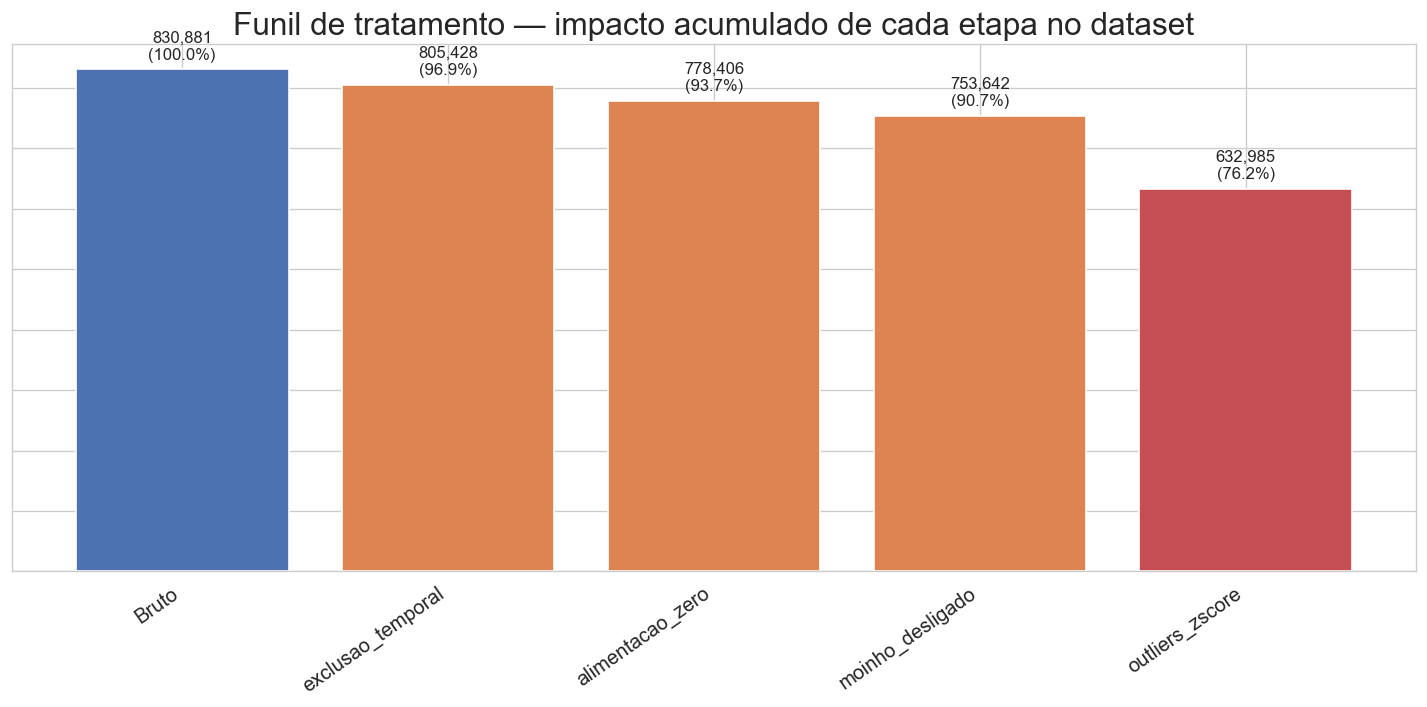


Retenção final: 632,985 de 830,881 registros (76.2%)


In [79]:
# ==============================================================================
# 8.1 Funil completo de tratamento — todas as etapas (limpeza + outliers)
# ==============================================================================

# Atualizar tabela de limpeza com a etapa de outliers
df_limpeza_final = pd.DataFrame(etapas_limpeza)
print("PIPELINE COMPLETA DE TRATAMENTO:")
display(df_limpeza_final)

# Funil: apenas etapas que removem linhas
etapas_funil = [e for e in etapas_limpeza if e["rows_removidas"] > 0]

fig, ax = plt.subplots(figsize=(12, 6))
etapas_nomes = ["Bruto"] + [e["etapa"].split("_", 1)[-1] for e in etapas_funil]
etapas_rows = [rows_inicio] + [e["rows_depois"] for e in etapas_funil]
colors = ["#4C72B0"] + ["#DD8452"] * (len(etapas_funil) - 1) + ["#C44E52"]  # última barra em vermelho (outliers)

ax.bar(etapas_nomes, etapas_rows, color=colors[:len(etapas_nomes)])
ax.set_ylabel("")
ax.set_yticklabels([])
ax.set_title("Funil de tratamento — impacto acumulado de cada etapa no dataset")
for i, v in enumerate(etapas_rows):
    pct = v / rows_inicio * 100
    ax.text(i, v + max(etapas_rows) * 0.015, f"{v:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=10)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()

fig.savefig(FIGURES_DIR / "S1a_03_funil_limpeza.png", dpi=150, bbox_inches="tight")
salvar_imagem("S1a", "funil_limpeza", fig, "S1a_03_funil_limpeza.png")
plt.show()

print(f"\nRetenção final: {len(df):,} de {rows_inicio:,} registros ({len(df)/rows_inicio*100:.1f}%)")

## 9 - Boxplots Antes vs Depois da Limpeza

**Objetivo:** Comparar visualmente a distribuição de cada variável antes e depois de todo o processo de limpeza (incluindo outliers), permitindo avaliar o impacto das remoções.

**Justificativa:** A comparação visual lado a lado é a forma mais direta de verificar se a limpeza foi efetiva — os boxplots do "depois" devem mostrar distribuições mais concentradas, sem whiskers extremos, confirmando que os dados remanescentes representam operação normal do moinho.

[db_utils] Imagem 'boxplot_antes_depois' salva para etapa S1a


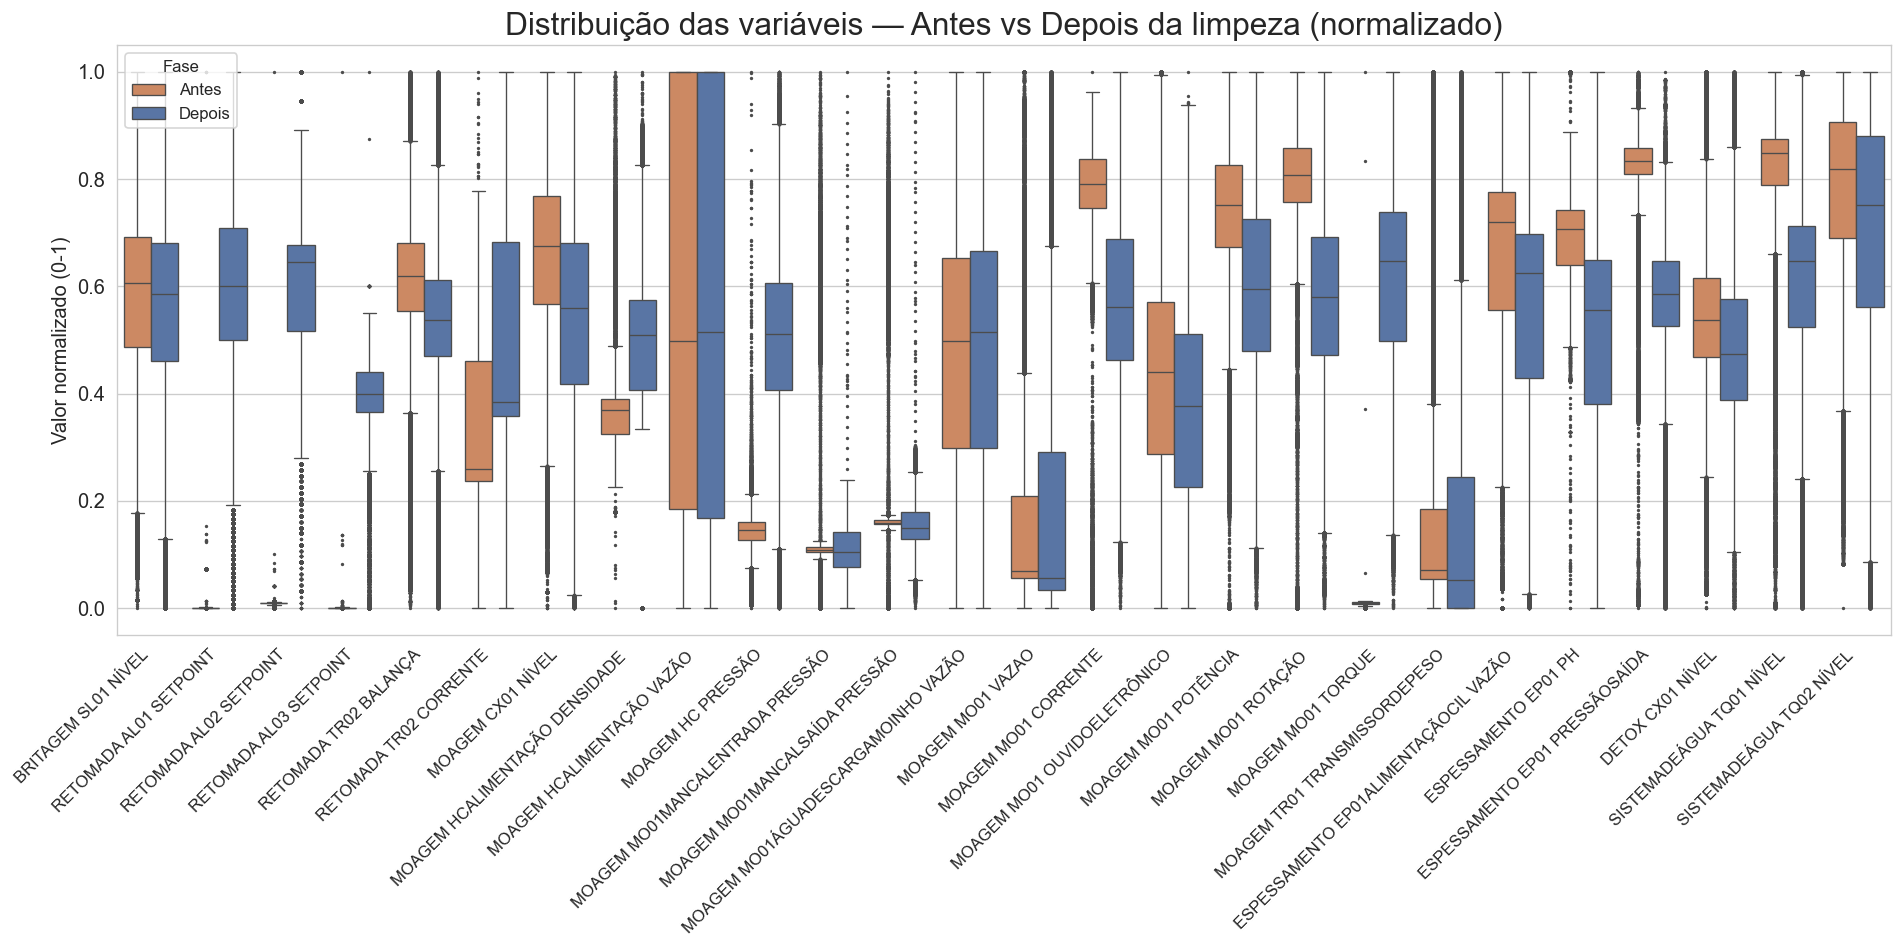

In [80]:
# ==============================================================================
# 9. Boxplots comparativos — antes vs depois (por variável, normalizado)
# ==============================================================================

# Normalizar ambos os datasets para comparação visual (escala 0-1)
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Usar apenas variáveis presentes em ambos os DataFrames
vars_plot = [v for v in VARIAVEIS if v in df.columns]

# Preparar dados normalizados (dropna em ambos para consistência)
df_antes_norm = pd.DataFrame(
    scaler.fit_transform(df_bruto[vars_plot].dropna()),
    columns=vars_plot
)
df_antes_norm["fase"] = "Antes"

df_depois_norm = pd.DataFrame(
    scaler.fit_transform(df[vars_plot].dropna()),
    columns=vars_plot
)
df_depois_norm["fase"] = "Depois"

# Concatenar e converter para formato longo para o boxplot
df_box = pd.concat([df_antes_norm, df_depois_norm], ignore_index=True)
df_box_long = df_box.melt(id_vars="fase", var_name="variavel", value_name="valor_normalizado")

# Criar nomes curtos para as variáveis (melhor visualização)
import re as _re
nomes_curtos = {}
for v in vars_plot:
    nome = v.replace("_pipoint", "").strip()
    nome = _re.sub(r"^\d{4}_", "", nome)
    nome = _re.sub(r"\s*_\s*", " ", nome).strip()
    nomes_curtos[v] = nome

df_box_long["var_curta"] = df_box_long["variavel"].map(nomes_curtos)

# Plotar boxplots lado a lado
fig, ax = plt.subplots(figsize=(16, 8))
sns.boxplot(
    data=df_box_long, x="var_curta", y="valor_normalizado",
    hue="fase", ax=ax, palette={"Antes": "#DD8452", "Depois": "#4C72B0"},
    fliersize=1, linewidth=0.8
)
ax.set_xlabel("")
ax.set_ylabel("Valor normalizado (0-1)")
ax.set_title("Distribuição das variáveis — Antes vs Depois da limpeza (normalizado)")
ax.legend(title="Fase")
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.tight_layout()

fig.savefig(FIGURES_DIR / "S1a_04_boxplot_antes_depois.png", dpi=150, bbox_inches="tight")
salvar_imagem("S1a", "boxplot_antes_depois", fig, "S1a_04_boxplot_antes_depois.png")
plt.show()

## 10 - Comparação Estatística Antes vs Depois

**Objetivo:** Gerar tabela comparativa das estatísticas descritivas (mean, std, min, max, mediana) de cada variável antes e depois de toda a limpeza.

**Justificativa:** A comparação numérica complementa os boxplots visuais. Permite verificar se as médias mudaram significativamente (indicando possível viés introduzido pela limpeza) e se os desvios diminuíram (indicando dados mais concentrados em torno da operação normal).

In [81]:
# ==============================================================================
# 10. Comparação estatística antes vs depois da limpeza completa
# ==============================================================================

# Estatísticas do dataset limpo (após limpeza + outliers)
stats_depois = df.describe().T
stats_depois.index.name = "variavel"

# Montar tabela comparativa apenas para variáveis presentes em ambos
vars_comparar = [c for c in VARIAVEIS if c in df.columns and c in stats_antes.index]

comparacao_rows = []
for col in vars_comparar:
    for stat in ["mean", "std", "min", "50%", "max"]:
        stat_nome = "mediana" if stat == "50%" else stat
        comparacao_rows.append({
            "variavel": col,
            "estatistica": stat_nome,
            "valor_antes": round(stats_antes.loc[col, stat], 4),
            "valor_depois": round(stats_depois.loc[col, stat], 4) if col in stats_depois.index else None,
        })

df_comparacao = pd.DataFrame(comparacao_rows)

# Exibir comparação de médias e desvios
print("Comparação de MÉDIAS (antes vs depois):")
comp_mean = df_comparacao[df_comparacao["estatistica"] == "mean"].copy()
comp_mean["variacao_%"] = ((comp_mean["valor_depois"] - comp_mean["valor_antes"]) / comp_mean["valor_antes"] * 100).round(2)
display(comp_mean[["variavel", "valor_antes", "valor_depois", "variacao_%"]])

print("\nComparação de DESVIOS PADRÃO (antes vs depois):")
comp_std = df_comparacao[df_comparacao["estatistica"] == "std"].copy()
comp_std["variacao_%"] = ((comp_std["valor_depois"] - comp_std["valor_antes"]) / comp_std["valor_antes"] * 100).round(2)
display(comp_std[["variavel", "valor_antes", "valor_depois", "variacao_%"]])

Comparação de MÉDIAS (antes vs depois):


,variavel,valor_antes,valor_depois,variacao_%
0,1010_BRITAGEM _ SL01 _ NÍVEL_pipoint,54.9251,55.0333,0.20
5,1025_RETOMADA _ AL01 _ SETPOINT_pipoint,73.4152,70.8624,-3.48
10,1025_RETOMADA _ AL02 _ SETPOINT_pipoint,91.7605,92.1815,0.46
15,1025_RETOMADA _ AL03 _ SETPOINT_pipoint,79.5374,79.6711,0.17
20,1025_RETOMADA _ TR02 _ BALANÇA_pipoint,236.2262,260.4184,10.24
25,1025_RETOMADA _ TR02 _ CORRENTE_pipoint,32.8891,35.3503,7.48
30,1030_MOAGEM _ CX01 _ NÍVEL_pipoint,67.4439,69.1510,2.53
35,1030_MOAGEM _ HCALIMENTAÇÃO _ DENSIDADE_pipoint,1706.7055,1689.0594,-1.03
40,1030_MOAGEM _ HCALIMENTAÇÃO _ VAZÃO_pipoint,787.5881,801.5285,1.77
45,1030_MOAGEM _ HC _ PRESSÃO_pipoint,0.5710,0.6075,6.39



Comparação de DESVIOS PADRÃO (antes vs depois):


,variavel,valor_antes,valor_depois,variacao_%
1,1010_BRITAGEM _ SL01 _ NÍVEL_pipoint,23.4395,23.5319,0.39
6,1025_RETOMADA _ AL01 _ SETPOINT_pipoint,154.1559,18.2715,-88.15
11,1025_RETOMADA _ AL02 _ SETPOINT_pipoint,18.0597,13.5191,-25.14
16,1025_RETOMADA _ AL03 _ SETPOINT_pipoint,78.5324,14.1170,-82.02
21,1025_RETOMADA _ TR02 _ BALANÇA_pipoint,84.0215,41.3199,-50.82
26,1025_RETOMADA _ TR02 _ CORRENTE_pipoint,14.4856,12.0589,-16.75
31,1030_MOAGEM _ CX01 _ NÍVEL_pipoint,15.9781,13.6433,-14.61
36,1030_MOAGEM _ HCALIMENTAÇÃO _ DENSIDADE_pipoint,238.2743,211.1318,-11.39
41,1030_MOAGEM _ HCALIMENTAÇÃO _ VAZÃO_pipoint,553.4993,552.0375,-0.26
46,1030_MOAGEM _ HC _ PRESSÃO_pipoint,0.1787,0.1217,-31.90


## 11 - Salvamento Final — Dataset Limpo e Metadados

**Objetivo:** Salvar o dataset limpo localmente (parquet) e no banco PostgreSQL, junto com todos os metadados de limpeza e outliers. Esse é o ponto de entrega do notebook — os dados ficam prontos para o próximo notebook (EDA).

**Saídas:**
- `data/processed/dataset_limpo.parquet` — arquivo local para backup e uso nos notebooks seguintes
- `otimizar_processo_pa.dados_limpos` — tabela no banco com os dados limpos
- `otimizar_processo_pa.s1a_resumo_limpeza` — registro de cada etapa de limpeza
- `otimizar_processo_pa.s1a_log_outliers` — limites e contagens de outliers por variável
- `otimizar_processo_pa.s1a_comparacao_estatisticas` — antes vs depois por variável

In [82]:
# ==============================================================================
# 11. Salvamento final — dataset limpo + metadados no banco e localmente
# ==============================================================================

# --- 11.1 Salvar dataset limpo localmente ---
ARQUIVO_LIMPO = DATA_PROC / "dataset_limpo.parquet"
df.to_parquet(ARQUIVO_LIMPO)
print(f"Dataset limpo salvo: {ARQUIVO_LIMPO}")
print(f"  Shape: {df.shape[0]:,} linhas x {df.shape[1]} colunas")

# --- 11.2 Salvar dataset limpo no banco ---
salvar_dataframe(df.reset_index(), "dados_limpos")

# --- 11.3 Salvar resumo de limpeza (atualizado com etapas de outlier) ---
df_limpeza_final = pd.DataFrame(etapas_limpeza)
salvar_dataframe(df_limpeza_final, "s1a_resumo_limpeza")

# --- 11.4 Salvar log de outliers ---
salvar_dataframe(df_log_outliers, "s1a_log_outliers")

# --- 11.5 Salvar comparação estatística antes vs depois ---
salvar_dataframe(df_comparacao, "s1a_comparacao_estatisticas")

print("\nTodos os dados e metadados salvos com sucesso.")

Dataset limpo salvo: C:\ScriptsDatamindsPIP\4-Projeto aplicado\data\processed\dataset_limpo.parquet
  Shape: 632,985 linhas x 26 colunas
[db_utils] dados_limpos: 500,000 / 632,985 (79.0%)
[db_utils] dados_limpos: 632,985 / 632,985 (100.0%)
[db_utils] 632,985 linhas salvas em otimizar_moagem_aura.dados_limpos
[db_utils] 8 linhas salvas em otimizar_moagem_aura.s1a_resumo_limpeza
[db_utils] 26 linhas salvas em otimizar_moagem_aura.s1a_log_outliers
[db_utils] 130 linhas salvas em otimizar_moagem_aura.s1a_comparacao_estatisticas

Todos os dados e metadados salvos com sucesso.


## 12 - Resumo Final do Notebook

**Objetivo:** Consolidar os resultados da preparação de dados em uma visão resumida para referência rápida e para o relatório do projeto.

In [83]:
# ==============================================================================
# 12. Resumo final — consolidação dos resultados
# ==============================================================================

print("=" * 60)
print("RESUMO FINAL — PREPARAÇÃO DOS DADOS (Sprint 1a)")
print("=" * 60)
print()
print(f"{'Registros brutos:':<35} {rows_inicio:>10,}")
for etapa in etapas_limpeza:
    nome = etapa["etapa"].split("_", 1)[-1]
    if etapa["rows_removidas"] > 0:
        print(f"  Após {nome + ':':<28} {etapa['rows_depois']:>10,}  (-{etapa['rows_removidas']:,})")
    elif "zero" in etapa["etapa"] or "mediana" in etapa["etapa"]:
        print(f"  {nome + ':':<30} {'(sem remoção de linhas)':>20}")
print(f"{'─' * 55}")
print(f"{'Registros finais (limpos):':<35} {len(df):>10,}")
print(f"{'Total removidos:':<35} {rows_inicio - len(df):>10,} ({(rows_inicio - len(df)) / rows_inicio * 100:.1f}%)")
print(f"{'Variáveis mantidas:':<35} {len(df.columns):>10}")
if colunas_removidas:
    print(f"{'Colunas removidas (Regra 2):':<35} {len(colunas_removidas)}")
    for col in colunas_removidas:
        print(f"  - {col}")
print(f"{'Período:':<35} {df.index.min()} a {df.index.max()}")
print()
print("Arquivos gerados:")
print(f"  Local:  {DATA_PROC / 'dataset_limpo.parquet'}")
print(f"  Banco:  otimizar_processo_pa.dados_brutos + dados_limpos")
print(f"  Banco:  s1a_resumo_extracao, s1a_resumo_negativos, s1a_resumo_ausentes")
print(f"  Banco:  s1a_gaps_ausentes, s1a_exclusoes_temporais, s1a_resumo_limpeza")
print(f"  Banco:  s1a_log_outliers, s1a_comparacao_estatisticas")
print(f"  Figs:   {FIGURES_DIR}")
print()
print("Próximo notebook: b_analise_exploratoria.ipynb")

RESUMO FINAL — PREPARAÇÃO DOS DADOS (Sprint 1a)

Registros brutos:                      830,881
  negativos_para_zero:           (sem remoção de linhas)
  Após exclusao_temporal:              805,428  (-25,453)
  Após alimentacao_zero:               778,406  (-27,022)
  Após moinho_desligado:               753,642  (-24,764)
  nan_regra3_mediana:            (sem remoção de linhas)
  Após outliers_zscore:                632,985  (-120,657)
───────────────────────────────────────────────────────
Registros finais (limpos):             632,985
Total removidos:                       197,896 (23.8%)
Variáveis mantidas:                         26
Colunas removidas (Regra 2):        1
  - 1025_RETOMADA_SL01_NIVEL_pipoint
Período:                            2024-08-01 00:00:00 a 2026-03-01 00:00:00

Arquivos gerados:
  Local:  C:\ScriptsDatamindsPIP\4-Projeto aplicado\data\processed\dataset_limpo.parquet
  Banco:  otimizar_processo_pa.dados_brutos + dados_limpos
  Banco:  s1a_resumo_extracao, s

In [84]:
# ==============================================================================
# Exportar notebook para HTML (com todos os outputs)
# ==============================================================================
from IPython.display import display, Javascript
import time

# 1. Forçar salvamento do notebook (grava outputs em disco)
display(Javascript("IPython.notebook.save_checkpoint()"))
time.sleep(3)  # Aguardar gravação

# 2. Exportar o .ipynb salvo para HTML
from nbconvert import HTMLExporter
import nbformat

_nb_path = PROJECT_ROOT / "notebooks" / "01_sprint1" / "a_preparacao_dados.ipynb"
_html_dir = PROJECT_ROOT / "html"
_html_dir.mkdir(parents=True, exist_ok=True)

with open(_nb_path, encoding="utf-8") as _f:
    _nb_node = nbformat.read(_f, as_version=4)

_exporter = HTMLExporter()
_exporter.exclude_input = True  # Ocultar código, manter outputs
(_html_body, _) = _exporter.from_notebook_node(_nb_node)

_out_path = _html_dir / "a_preparacao_dados.html"
_out_path.write_text(_html_body, encoding="utf-8")
print("HTML exportado:", _out_path)

<IPython.core.display.Javascript object>

HTML exportado: C:\ScriptsDatamindsPIP\4-Projeto aplicado\html\a_preparacao_dados.html
